In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import io
import typing

import mne
import numpy
import scipy
import pandas
import cairosvg
import PIL.Image
import matplotlib.pyplot as plt
import matplotlib.offsetbox as mob

import SDA.analytics

In [5]:
def draw_eeg(src_folder, results_folder, ax, title: str):
    raw_data = mne.io.read_raw_fif(f"{src_folder}/data.fif", verbose='error')
    epochs = mne.read_epochs(f"{src_folder}/epochs.fif", verbose='error')
    raw_data.crop(epochs.events[0][0] / epochs.info['sfreq'], epochs.events[-1][0] / epochs.info['sfreq'])
    edges_true = numpy.loadtxt(f"{src_folder}/edges.txt").astype(int)
    
    best_edges = numpy.loadtxt(f"{results_folder}/best_edges.txt").astype(int)
    pca_features = numpy.load(f"{results_folder}/pca_features.npy")
    df_st_edges = pandas.read_csv(f"{results_folder}/df_st_edges.csv")
    best_result = pandas.read_csv(f"{results_folder}/best_result.csv").iloc[0]

    st_edges_list = [ ]
    for st_edges in df_st_edges["St_edges"]:
        st_edges = numpy.fromstring(st_edges.strip('[]'), sep = ' ', dtype = numpy.uint)
        st_edges_list.append(st_edges)
    df_st_edges["St_edges"] = st_edges_list

    ax.set_title(f"{title}. Average Silhouette: {round(best_result['Avg-Silh'], 2)}. FMI: {round(best_result['FMI'], 2)}")
    SDA.analytics.plot_eeg_stages(
        raw_data, best_edges, epochs, pca_features, df_st_edges, best_result,
        ax = ax, resolution = 30, scale_data = True, edges_true = edges_true
    )

def draw(subj, subj_name, exp):
    traditional = f"{subj}/{exp}/results/traditional"
    topological = f"{subj}/{exp}/results/topological"
    combined = f"{subj}/{exp}/results/combined"

    fig, axes = plt.subplots(3, 1, figsize=(40, 30))
    fig.suptitle(f"Subject {subj_name}", fontsize = 36, fontweight = 'bold')
    
    draw_eeg(subj, traditional, axes[0], title = "Traditional features")
    draw_eeg(subj, topological, axes[1], title = "Topological features")
    draw_eeg(subj, combined, axes[2], title = "Combined features")
    
    fig.tight_layout()
    return fig

In [6]:
def get_silh(src_folder, subj, exp, result):
    best_result = pandas.read_csv(f"{src_folder}/{subj}/{exp}/results/{result}/best_result.csv").iloc[0]
    return round(best_result['Avg-Silh'], 3)

def get_fmi(src_folder, subj, exp, result):
    best_result = pandas.read_csv(f"{src_folder}/{subj}/{exp}/results/{result}/best_result.csv").iloc[0]
    return round(best_result['FMI'], 3)

def draw_bars_one(extractor, ax, title: str, y_lim = None):
    traditional = [ extractor("sleep-edf", f"Subj{i}", "exp_reduced_flow", "traditional") for i in range(0, 153) ]
    topological = [ extractor("sleep-edf", f"Subj{i}", "exp_reduced_flow", "topological") for i in range(0, 153) ]
    combined =    [ extractor("sleep-edf", f"Subj{i}", "exp_reduced_flow", "combined")    for i in range(0, 153) ]

    WIDTH = 0.25
    x = numpy.array(range(1, 154))

    ax.bar(x, traditional, width = WIDTH, color = (0, 0.5, 1), label = 'Traditional')
    ax.bar(x + WIDTH, topological, width = WIDTH, color = (0, 0.66, 0), label = 'Topological')
    ax.bar(x + 2 * WIDTH, combined, width = WIDTH, color = (1, 0.5, 0), label = 'Combined')

    ax.set_xticks(x + WIDTH, x)
    ax.tick_params(labelrotation=45)
    ax.set_xlim(-2, 154)
    ax.set_title(title)
    if y_lim:
        ax.set_ylim(*y_lim)
    ax.legend(ncol = 3, loc = 'upper left')

def draw_bars():
    fig, axes = plt.subplots(2, 1, figsize = (60, 15))
    fig.suptitle("Quality scores of the resulting boundaries.", fontsize = 36, fontweight = 'bold')
    draw_bars_one(get_silh, axes[0], "Silhouette coefficient")
    draw_bars_one(get_fmi, axes[1], "Fowlkes-Mallows index compared to target stages.", y_lim = (0.5, 1.1))
    fig.tight_layout()
    return fig

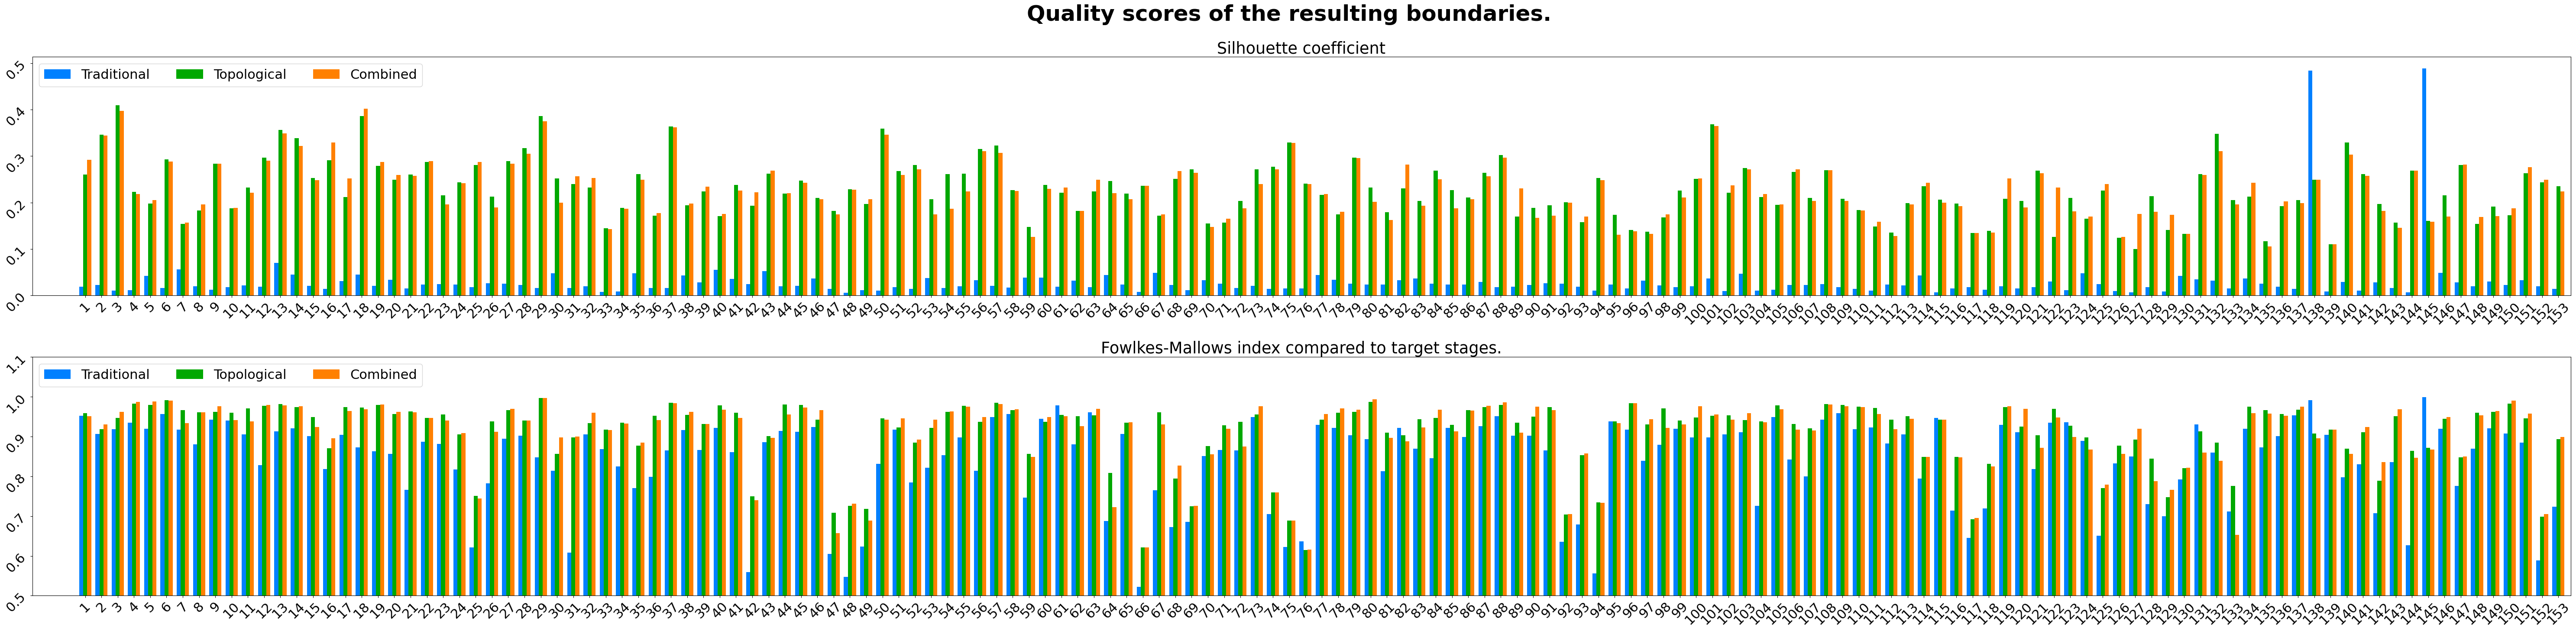

In [ ]:
import tqdm
from matplotlib.backends.backend_pdf import PdfPages


pp = PdfPages('sda_supplementary_sleep.pdf')

plt.rcParams.update({'font.size': 22})
pp.savefig(draw_bars())

plt.rcParams.update({'font.size': 28})
for i in tqdm.trange(0, 153, 1):
    pp.savefig(draw(f"sleep-edf/Subj{i}", i + 1, "exp_reduced_flow"))
pp.close()

In [23]:
def get_ci(data):
    data = numpy.array(data)
    alpha = 0.05
    n = len(data)
    std = data.std(ddof=1)
    t_crit = scipy.stats.t.ppf(1 - alpha / 2, df = n-1)
    return round(data.mean(), 3), round(t_crit * std / numpy.sqrt(n), 3)

def print_ci(stat, type):
    data = [ stat("sleep-edf", f"Subj{i}", "exp_reduced_flow", type) for i in range(0, 153) ]
    print(f"{type} {stat.__name__[4:]}: {get_ci(data)[0]} +- {get_ci(data)[1]}")

print_ci(get_silh, "traditional")
print_ci(get_silh, "topological")
print_ci(get_silh, "combined")
print('-----------------------')
print_ci(get_fmi, "traditional")
print_ci(get_fmi, "topological")
print_ci(get_fmi, "combined")

traditional silh: 0.03 +- 0.009
topological silh: 0.228 +- 0.01
combined silh: 0.227 +- 0.01
-----------------------
traditional fmi: 0.843 +- 0.017
topological fmi: 0.911 +- 0.013
combined fmi: 0.907 +- 0.014


In [42]:
def get_ci(data, alpha = 0.05):
    data = numpy.array(data)
    n = len(data)
    std = data.std(ddof=1)
    t_crit = scipy.stats.t.ppf(1 - alpha / 2, df = n-1)
    return round(data.mean(), 3), round(t_crit * std / numpy.sqrt(n), 3)

def print_ci(stat, type):
    data = [ stat("sleep-edf", f"Subj{i}", "exp_reduced_flow", type) for i in range(0, 153) ]
    print(f"{type} {stat.__name__[4:]}: {get_ci(data)[0]} +- {get_ci(data)[1]}; min = {numpy.percentile(data, 35):.4f}, max = {numpy.percentile(data, 50):.4f}")

print_ci(get_silh, "traditional")
print_ci(get_silh, "topological")
print_ci(get_silh, "combined")
print('-----------------------')
print_ci(get_fmi, "traditional")
print_ci(get_fmi, "topological")
print_ci(get_fmi, "combined")

traditional silh: 0.03 +- 0.009; min = 0.0180, max = 0.0220
topological silh: 0.228 +- 0.01; min = 0.2042, max = 0.2230
combined silh: 0.227 +- 0.01; min = 0.1960, max = 0.2220
-----------------------
traditional fmi: 0.843 +- 0.017; min = 0.8396, max = 0.8810
topological fmi: 0.911 +- 0.013; min = 0.9212, max = 0.9420
combined fmi: 0.907 +- 0.014; min = 0.9152, max = 0.9400


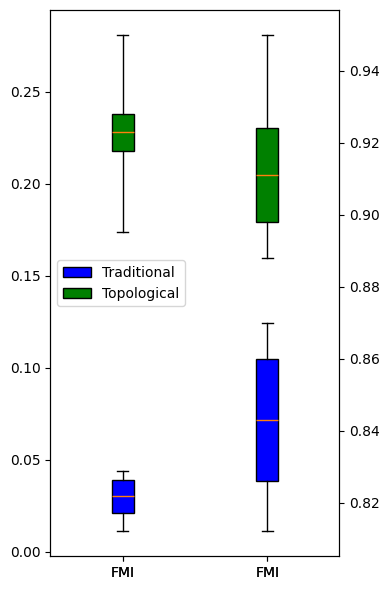

In [ ]:
import matplotlib.pyplot as plt

silh_stats = [
    { "med": 0.030, "q1": 0.03 - 0.009, "q3": 0.03 + 0.009, "whislo": 0.0110, "whishi": 0.0438 },
    { "med": 0.228, "q1": 0.228 - 0.01, "q3": 0.228 + 0.01, "whislo": 0.1740, "whishi": 0.2810 }
]

fmi_stats = [
    { "med": 0.843, "q1": 0.843 - 0.017, "q3": 0.843 + 0.017, "whislo": 0.812, "whishi": 0.87 },
    { "med": 0.911, "q1": 0.911 - 0.013, "q3": 0.911 + 0.013, "whislo": 0.888, "whishi": 0.95 }
]

colors = ["blue", "green"]
labels = ["Traditional", "Topological"]

fig, ax = plt.subplots(figsize=(4, 6))
ax2 = ax.twinx()

bp = ax.bxp(silh_stats, showfliers=False, patch_artist=True, positions = [ 1, 1 ])
for patch, color, label in zip(bp["boxes"], colors, labels):
    patch.set_facecolor(color)

bp2 = ax2.bxp(fmi_stats, showfliers=False, patch_artist=True, positions = [ 2, 2 ])
for patch, color, label in zip(bp2["boxes"], colors, labels):
    patch.set_facecolor(color)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, edgecolor="black", label=l)
                  for c, l in zip(colors, labels)]
plt.legend(handles = legend_handles, loc = 'center left')

ax.set_xticklabels([ "Silh", "Silh", "FMI", "FMI" ])
plt.tight_layout()
plt.show()
fig.savefig("ga_sleep.svg")

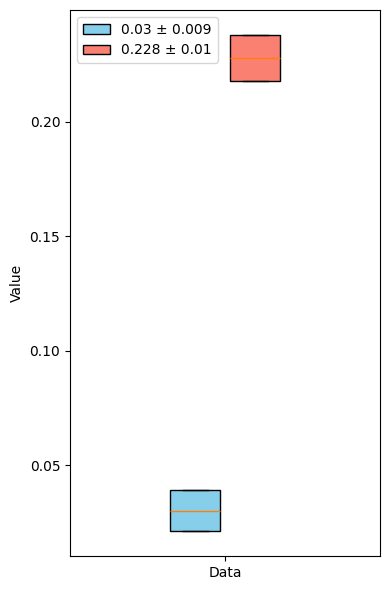

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Custom boxplot stats from value ± error
stats1 = {
    "med": 0.03,
    "q1": 0.03 - 0.009,
    "q3": 0.03 + 0.009,
    "whislo": 0.03 - 0.009,
    "whishi": 0.03 + 0.009,
    "fliers": []
}
stats2 = {
    "med": 0.228,
    "q1": 0.228 - 0.01,
    "q3": 0.228 + 0.01,
    "whislo": 0.228 - 0.01,
    "whishi": 0.228 + 0.01,
    "fliers": []
}

fig, ax = plt.subplots(figsize=(4, 6))

# Same x position, small offset so boxes don't completely overlap
x_center = 1
offset = 0.12
positions1 = [x_center - offset]
positions2 = [x_center + offset]

# First box
bp1 = ax.bxp(
    [stats1],
    positions=positions1,
    widths=0.2,
    showfliers=False,
    patch_artist=True,
)
bp1["boxes"][0].set_facecolor("skyblue")
bp1["boxes"][0].set_edgecolor("black")

# Second box
bp2 = ax.bxp(
    [stats2],
    positions=positions2,
    widths=0.2,
    showfliers=False,
    patch_artist=True,
)
bp2["boxes"][0].set_facecolor("salmon")
bp2["boxes"][0].set_edgecolor("black")

# X-axis label and ticks (single x location)
ax.set_xticks([x_center])
ax.set_xticklabels(["Data"])

# Legend
legend_handles = [
    Patch(facecolor="skyblue", edgecolor="black", label="0.03 ± 0.009"),
    Patch(facecolor="salmon", edgecolor="black", label="0.228 ± 0.01"),
]
ax.legend(handles=legend_handles, loc="best")

ax.set_ylabel("Value")
plt.tight_layout()
plt.show()
